# Grid2Op observations
Grid2Op returns instances of type CompleteObservations for the agents to work with.

In [1]:
import grid2op
from grid2op.gym_compat import GymEnv

env_name = "l2rpn_case14_sandbox"
env = grid2op.make(env_name)
obs = env.reset()
print(f"Normally observation are of type: {obs.__class__.__name__}")

Normally observation are of type: CompleteObservation_l2rpn_case14_sandboxPandaPowerBackend


This is not directly compatible with RL. Therefore, they provide wrappers that convert these instances to Gymnasium like observation spaces like Dict, Box, etc. Typically we can just use the GymEnv wrapper:

In [2]:
gym_env = GymEnv(env)
obs = gym_env.reset()
print(f"Observation compatible with gymnasium:\n{obs}")

Observation compatible with gymnasium:
(OrderedDict({'_shunt_bus': array([1], dtype=int32), '_shunt_p': array([0.], dtype=float32), '_shunt_q': array([-21.171331], dtype=float32), '_shunt_v': array([21.111898], dtype=float32), 'a_ex': array([ 162.08841 ,  139.10452 ,  100.85153 ,  149.95692 ,  121.001595,
         60.33986 ,  129.50453 ,  398.10004 ,  254.13318 ,  635.25415 ,
         11.118516,  202.50722 ,  284.00537 ,   71.89418 ,  294.01556 ,
       1054.9656  ,  348.76956 ,  672.1114  , 1038.5555  ,  873.0285  ],
      dtype=float32), 'a_or': array([169.15834 , 139.39386 , 105.20001 , 149.66953 , 120.84918 ,
        57.011944, 129.50453 , 398.10004 , 254.13318 , 635.25415 ,
        11.118516, 202.50722 , 284.00537 ,  71.89418 , 294.01556 ,
       109.433014,  52.16338 , 104.514435, 890.1904  , 611.12    ],
      dtype=float32), 'actual_dispatch': array([0., 0., 0., 0., 0., 0.], dtype=float32), 'attention_budget': array([0.], dtype=float32), 'current_step': array([0], dtype=int32),

# Graph Observations
The above observation is a dict and therefore part of the Dict observation space of gymnasium. For our purposes we want to observe the powergrid as graph. We want to have a set of nodes and edges each having some features. This is not implemented by default in grid2op. For this reason, I implemented a custom observation space that represents the powergrid as a graph in the following way:
- Nodes: Connections between buses and powerline-endpoints/loads/generators
- Edges: Connect both endpoints of the same powerline. Connect endpoints of different powerlines if they are connected to the same substation and the same bus.

/tmp/ipykernel_92699/3486873993.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


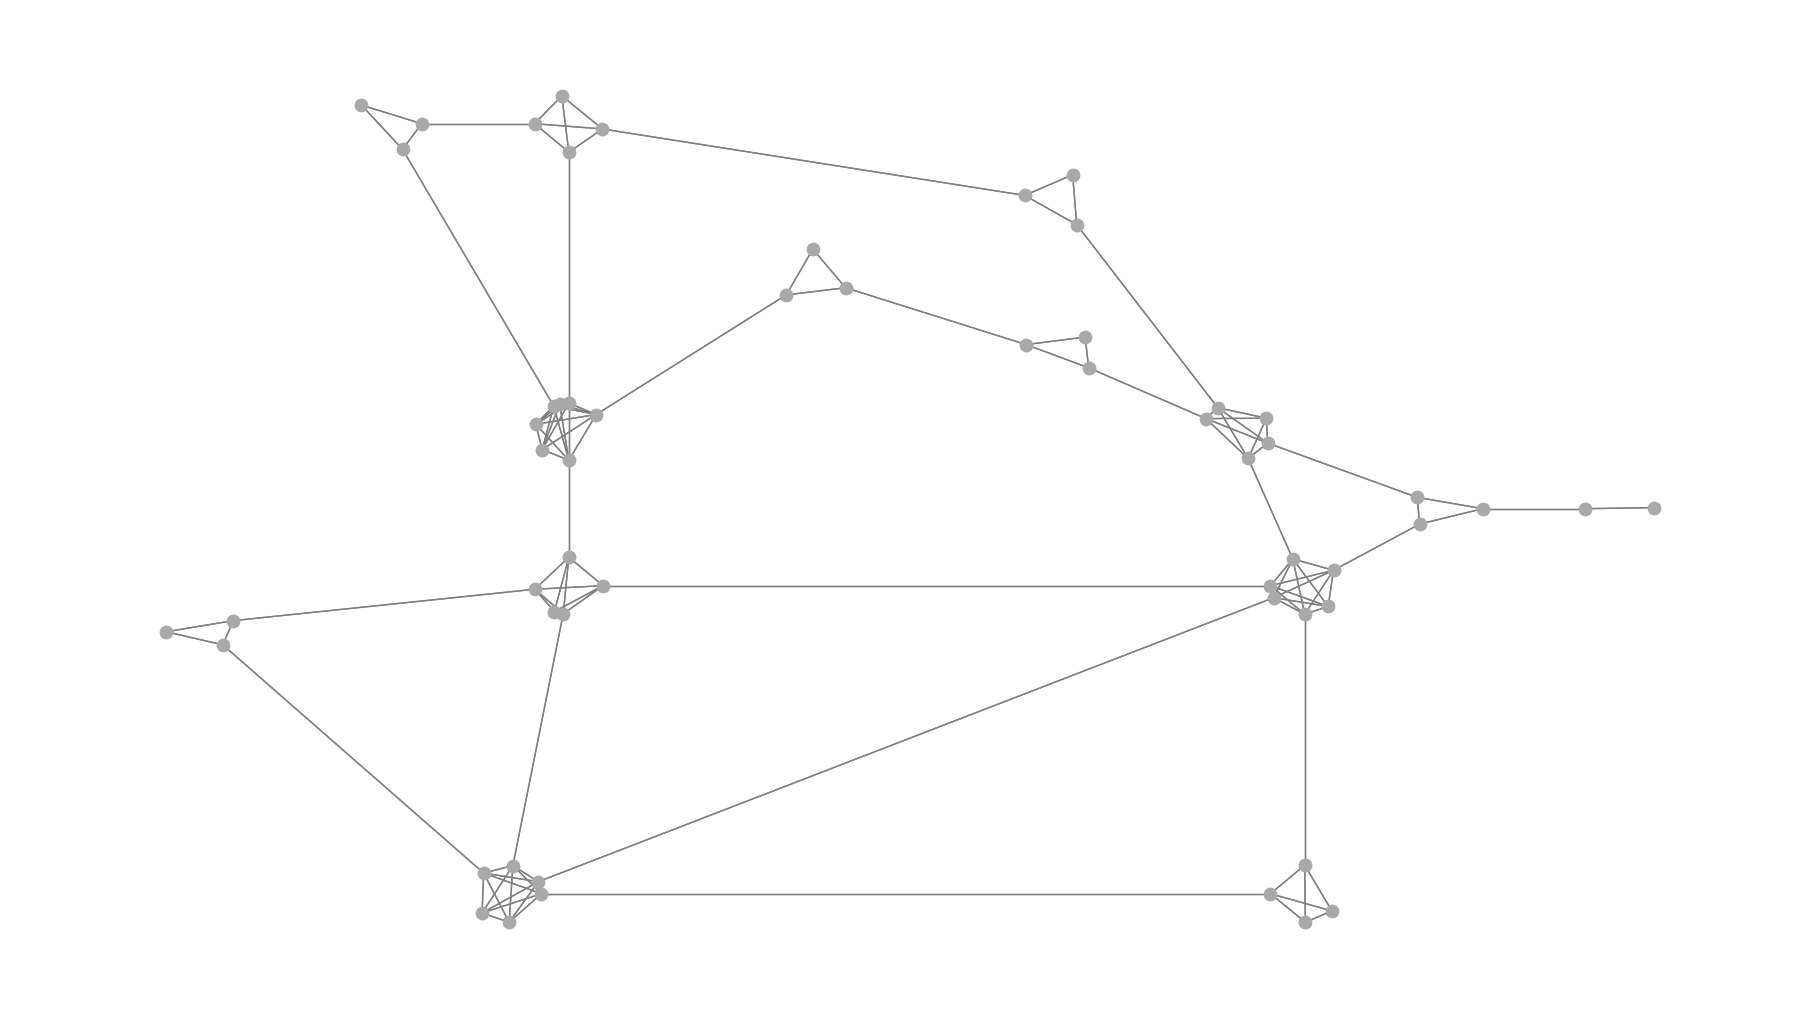

In [3]:
from visualization.utils import visualize_graph, get_node_positions
from common.graph_structured_observation_space import BusConnectionsGraphObsSpace, EDGE_INDEX

env = grid2op.make(env_name)
g2op_obs = env.reset()
obs_space = BusConnectionsGraphObsSpace(env.observation_space)
edge_index = obs_space.to_gym(g2op_obs)[EDGE_INDEX]
fig = visualize_graph(obs_space.num_node, edge_index=edge_index, node_positions=get_node_positions(env, obs_space.__class__))
fig.show()

We can use the observation space like this:


In [4]:
from common import Grid2OpEnvWrapper

graph_env = Grid2OpEnvWrapper(env_name, obs_space_creation=lambda e: BusConnectionsGraphObsSpace(e.observation_space))
obs, _ = graph_env.reset()

The returned observations follow the Dict observation space scheme by gymnasium and include the following information:
## Node features
In this representation edges don't have features. Node features include:
- active/reactive power
- voltage + voltage angle
- current
- rho

The node features are stored as an array of shape `[num_nodes, num_features]`.

In [5]:
from common.graph_structured_observation_space import NODES
print(f"Shape: {obs[NODES].shape}")
obs[NODES]

Shape: (57, 6)


array([[ 4.13398514e+01, -1.57593794e+01,  1.42100006e+02,
         0.00000000e+00,  1.79753983e+02,  3.32262456e-01],
       [ 4.05496712e+01, -8.99412334e-01,  1.42100006e+02,
         0.00000000e+00,  1.64793259e+02,  3.66207242e-01],
       [ 2.45431957e+01, -7.52687645e+00,  1.42100006e+02,
        -1.45767343e+00,  1.04302650e+02,  2.78140396e-01],
       [ 4.29977684e+01,  7.23460078e-01,  1.42100006e+02,
        -1.45767343e+00,  1.74724045e+02,  2.74723351e-01],
       [ 3.68558197e+01, -2.30466470e-01,  1.42100006e+02,
        -1.45767343e+00,  1.49747574e+02,  8.55700433e-01],
       [ 1.78642426e+01,  8.14170837e+00,  1.42100006e+02,
        -4.21646738e+00,  7.97648544e+01,  2.79876679e-01],
       [-2.75292625e+01, -2.48339176e+00,  1.38513351e+02,
        -5.58270121e+00,  1.15213203e+02,  3.43920022e-01],
       [ 7.73931313e+00,  1.07921219e+01,  2.20000000e+01,
        -9.91381168e+00,  3.48517975e+02,  5.30468762e-01],
       [ 7.59530306e+00,  5.67776537e+00,  2.200

## Edge Index
Adjacency information is stored in the edge index. Normally this array has shape `[2, num_edges]` and contains the 2 adjacent node indices for every edge.
Since gymnasium dictates fixed sized outputs this approach cannot directly handle a flexible number of edges. Therefore, in our case the edge_index has dimension `[2, max_edges]`, where max_edges is the amount of edges we have when everything is connected to bus 1. If we have less than `max_edges` edges we add padding to the output.

In [6]:
from common.graph_structured_observation_space import EDGE_INDEX
print(f"Shape: {obs[EDGE_INDEX].shape}")
obs[EDGE_INDEX]

Shape: (2, 244)


array([[ 0,  1,  0, 45,  1, 45,  2,  3,  2,  4,  2, 20,  2, 40,  2, 46,
         3,  4,  3, 20,  3, 40,  3, 46,  4, 20,  4, 40,  4, 46,  5, 22,
         5, 41,  5, 47,  6, 15,  6, 16,  6, 23,  6, 25,  6, 48,  7,  8,
         7,  9,  7, 37,  7, 42,  7, 43,  7, 50,  8,  9,  8, 37,  8, 42,
         8, 43,  8, 50,  9, 37,  9, 42,  9, 43,  9, 50, 10, 11, 10, 19,
        10, 36, 10, 51, 11, 19, 11, 36, 11, 51, 12, 30, 12, 52, 13, 28,
        13, 54, 14, 29, 14, 33, 14, 55, 15, 16, 15, 23, 15, 25, 15, 48,
        16, 23, 16, 25, 16, 48, 17, 21, 17, 24, 17, 26, 17, 49, 18, 35,
        18, 39, 19, 36, 19, 51, 20, 40, 20, 46, 21, 24, 21, 26, 21, 49,
        22, 41, 22, 47, 23, 25, 23, 48, 24, 26, 24, 49, 25, 48, 26, 49,
        27, 32, 27, 53, 28, 54, 29, 33, 29, 55, 30, 52, 31, 34, 31, 56,
        32, 53, 33, 55, 34, 56, 35, 39, 36, 51, 37, 42, 37, 43, 37, 50,
        38, 44, 40, 46, 41, 47, 42, 43, 42, 50, 43, 50,  0, 20,  1, 21,
         2, 22,  3, 23,  4, 24,  5, 25,  6, 26,  7, 27,  8, 28, 

## Edge Mask
As described we pad our edge index until it has the desired dimension. However, we do not actually want to use the edges that are encoded by our padding. Therefore `edge_mask` encodes which edges are part of our observation and which edges are part of our padding. So far, every edge is real since everything is connected to bus 1.

In [7]:
from common.graph_structured_observation_space import EDGE_MASK
print(f"Shape: {obs[EDGE_MASK].shape}")
obs[EDGE_MASK]

Shape: (244,)


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

If we apply a topological action, something will be reconnected to another bus and we have less real edges. Generally, the edge mask helps us to retrieve the real edge index from batched observations.

Shape: (244,)
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True 

/tmp/ipykernel_92699/4020133017.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


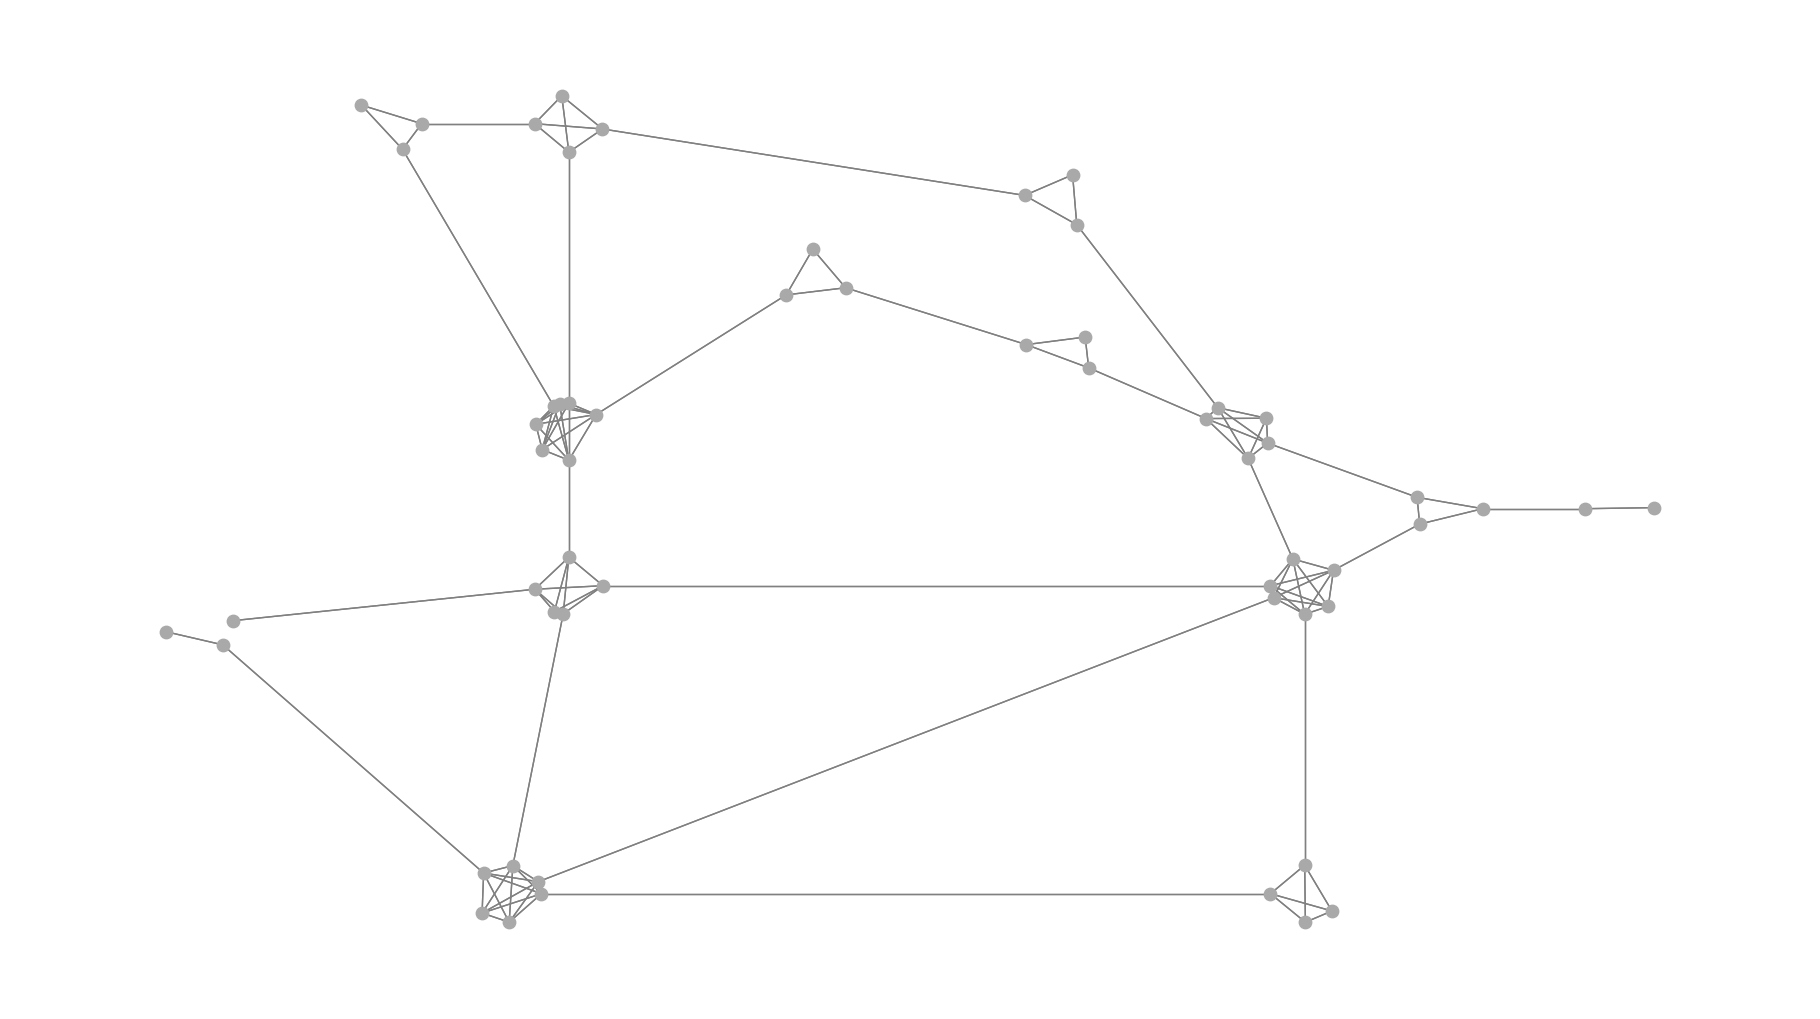

In [8]:
obs, _, _, _, _ = graph_env.step(2)
print(f"Shape: {obs[EDGE_MASK].shape}")
print(obs[EDGE_MASK])

edge_index = obs[EDGE_INDEX][:,obs[EDGE_MASK]]
fig = visualize_graph(num_nodes=obs_space.num_node, edge_index=edge_index, node_positions=get_node_positions(env, obs_space.__class__))
fig.show()

Note that the leftmost substation is no longer fully connected.

# 36 Nodes grid

/home/adrian/.conda/envs/RL/lib/python3.12/site-packages/grid2op/MakeEnv/Make.py:509: UserWarning: It is the first time you use the environment "l2rpn_wcci_2020".
We will attempt to download this environment from remote
  warnings.warn(_MAKE_FIRST_TIME_WARN.format(dataset_name))


downloading the training data, this may take a while.


l2rpn_wcci_2020.tar.bz2: 4.55GB [12:14, 6.19MB/s]                               


Extract the tar archive in "/home/adrian/data_grid2op"
	 Successfully updated file "config.py" for environment "l2rpn_wcci_2020"
	 Successfully updated file "grid.json" for environment "l2rpn_wcci_2020"
You may now use the environment "l2rpn_wcci_2020" with the available data by invoking:
	env = grid2op.make("l2rpn_wcci_2020")


/tmp/ipykernel_92699/2082577755.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_36.show()


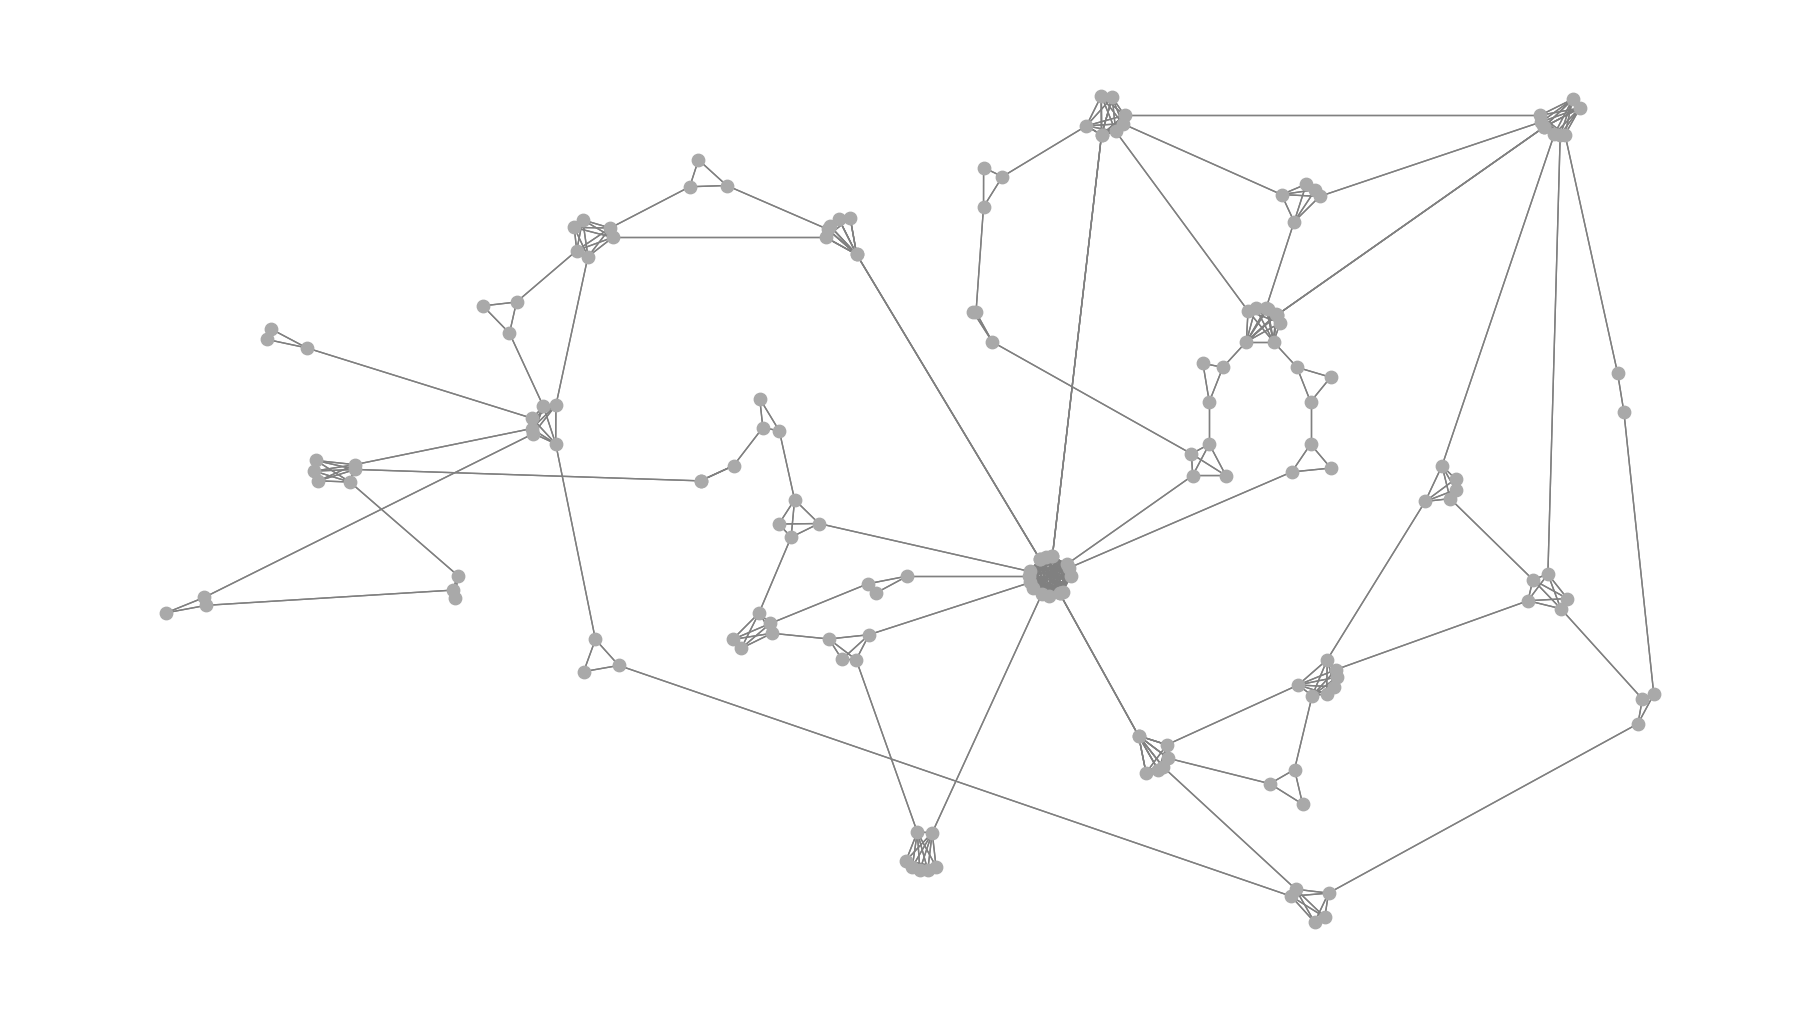

In [9]:
env_36 = grid2op.make("l2rpn_wcci_2020")
g2op_obs_36 = env_36.reset()
obs_space_36 = BusConnectionsGraphObsSpace(env_36.observation_space)
edge_index_36 = obs_space_36.to_gym(g2op_obs_36)[EDGE_INDEX]
fig_36 = visualize_graph(obs_space_36.num_node, edge_index=edge_index_36, node_positions=get_node_positions(env_36, obs_space.__class__))
fig_36.show()

# 118 Nodes grid

/tmp/ipykernel_92699/1814856905.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_118.show()


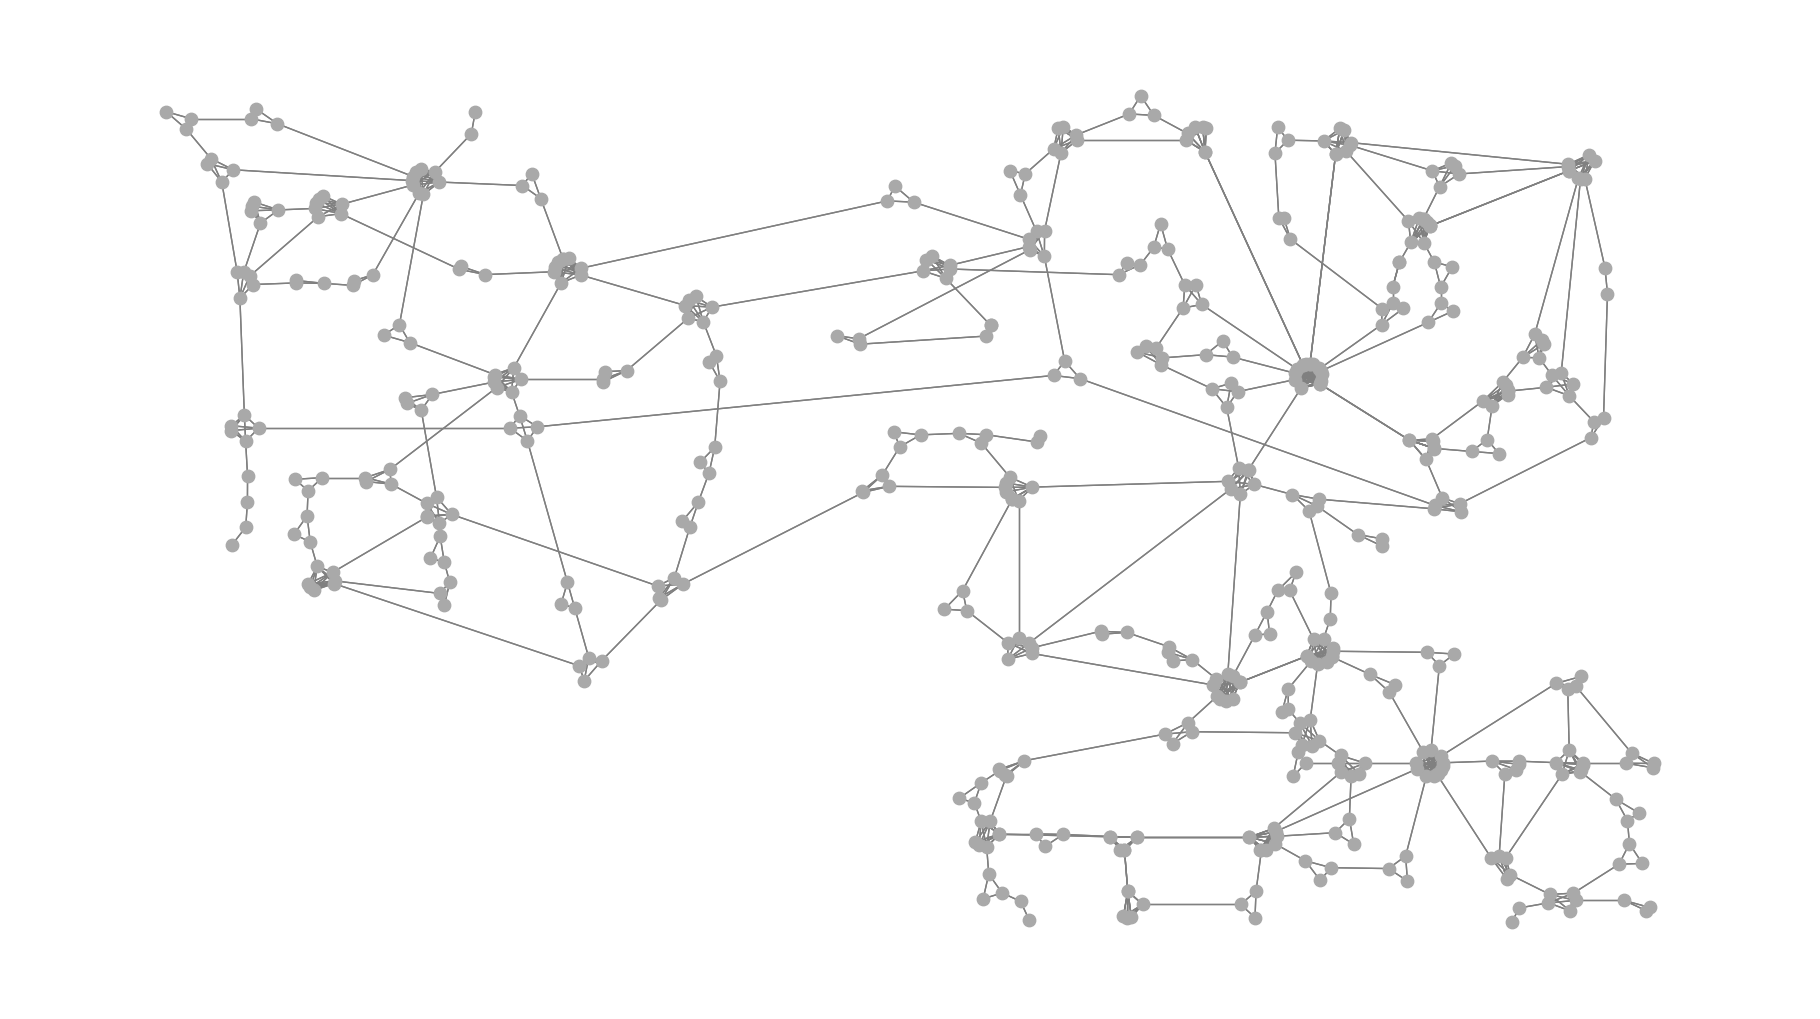

In [10]:
env_118 = grid2op.make("l2rpn_idf_2023")
g2op_obs_118 = env_118.reset()
obs_space_118 = BusConnectionsGraphObsSpace(env_118.observation_space)
edge_index_118 = obs_space_118.to_gym(g2op_obs_118)[EDGE_INDEX]
fig_118 = visualize_graph(obs_space_118.num_node, edge_index=edge_index_118, node_positions=get_node_positions(env_118, obs_space.__class__))
fig_118.show()